# flow2 Phase 6P：推理阶段地球物理极限测试结果

**案例：`cond_generation_0`｜观测：Phase 4C truth-derived convolutional seismic｜日期：2026-08-02**

本 Notebook 展示两个已经完成的训练前诊断：

1. 与 Phase 4C 完全同轨迹的 `0.25/0.5/1/2/4×` 地震制导阶梯；
2. 冻结网络、从基线连续终点出发的 200 步 endpoint physics fitting。

所有图都直接读取已保存的 `.pt/.csv/.json`。执行本 Notebook不会重新采样、不会训练、不会覆盖实验目录。地质真值评价是在物理运行结果冻结后由独立 auditor 完成。

**核心结论：** 推理制导从 0.25× 拉到 4× 后，硬地震 RMSE 最多只消除 9.88%；继续加权会明显破坏三维地质。endpoint 的 soft seismic 可以持续改善，但 hard seismic 很快分叉并恶化，说明当前主要瓶颈是冻结轨迹/decoder 与物理目标不对齐，而不是“已经拟合地震后的非唯一解”。

## 1. 初始化与权威结果定位

路径定位支持从仓库根目录或项目目录运行。所有关键资产缺失时立即失败。

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager, colors as mcolors
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
cjk_font_path = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if cjk_font_path.is_file():
    font_manager.fontManager.addfont(str(cjk_font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(cjk_font_path)).get_name()
else:
    plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 5)

def locate_project() -> Path:
    starts = [Path.cwd().resolve(), Path.cwd().resolve() / "project" / "geodata-3d-conditional"]
    for start in starts:
        for base in [start, *start.parents]:
            for candidate in (base, base / "project" / "geodata-3d-conditional"):
                if (candidate / "docs" / "PHASE6P_REPORT.md").is_file():
                    return candidate.resolve()
    raise FileNotFoundError("无法定位 project/geodata-3d-conditional")

PROJECT = locate_project()
ENDPOINT = PROJECT / "experiments/stage6_geo_adapter/runs/cond_generation_0/physics_attainment_seismic_endpoint_v1_specfinal"
LADDER = PROJECT / "experiments/stage6_geo_adapter/runs/cond_generation_0/physics_attainment_seismic_trajectory_ladder_v1"
OBSERVATION = PROJECT / "experiments/stage4_seismic/observations/cond_generation_0/distinct_upper_bound_v1_fix2"
TRUTH_PATH = PROJECT / "samples/jupyter-demo/cond_generation_0/true_model.pt"

def load_json(path: Path):
    if not path.is_file():
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))

def load_csv(path: Path):
    if not path.is_file():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_volume(path: Path) -> np.ndarray:
    if not path.is_file():
        raise FileNotFoundError(path)
    value = torch.load(path, map_location="cpu", weights_only=True)
    array = value.detach().cpu().numpy() if hasattr(value, "detach") else np.asarray(value)
    return np.squeeze(array)

required = [
    ENDPOINT / "config.json", ENDPOINT / "optimization_trace.csv",
    ENDPOINT / "truth_audit/summary.json", ENDPOINT / "best_sample.pt",
    LADDER / "config.json", LADDER / "ladder_metrics.csv",
    LADDER / "truth_audit/summary.json", LADDER / "baseline_sample.pt",
    OBSERVATION / "observed_seismic.pt", TRUTH_PATH,
]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("缺少 Phase 6P 权威资产:\n" + "\n".join(missing))

print("PROJECT =", PROJECT)
print("Endpoint engineering pass =", load_json(ENDPOINT / "config.json")["engineering_pass"])
print("Ladder engineering pass   =", load_json(LADDER / "config.json")["engineering_pass"])

PROJECT = /home/xmj/mcy/flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional
Endpoint engineering pass = True
Ladder engineering pass   = True


## 2. 具体数值：制导强度增加后发生了什么？

物理达到率定义为 `1 - RMSE_guided / RMSE_baseline`。达到率 100% 才表示 RMSE 在该尺度上被完全消除；本实验预先把 `<25%` 定义为低可达。

In [2]:
endpoint_config = load_json(ENDPOINT / "config.json")
endpoint_audit = load_json(ENDPOINT / "truth_audit/summary.json")
ladder_config = load_json(LADDER / "config.json")
ladder_audit = load_json(LADDER / "truth_audit/summary.json")
ladder_physics = load_csv(LADDER / "ladder_metrics.csv")
ladder_geology = load_csv(LADDER / "truth_audit/sample_metrics.csv")
endpoint_trace = load_csv(ENDPOINT / "optimization_trace.csv")

baseline_geo = ladder_geology.query("role == 'baseline'").iloc[0]
geo_index = ladder_geology.set_index("role")
rows = []
for _, physical in ladder_physics.iterrows():
    geology = geo_index.loc[physical["id"]]
    rows.append({
        "方法": physical["id"],
        "强度/上限": physical["alpha"],
        "hard seismic RMSE": physical["hard_seismic_rmse_amplitude"],
        "物理达到率": physical["attainment"],
        "场更新/所需残差": physical["update_to_required_residual_norm_ratio"],
        "更新方向余弦": physical["update_residual_cosine"],
        "hard 改动比例": physical["changed_from_baseline_fraction"],
        "全局 mIoU": geology["global_mean_iou"],
        "Δ全局 mIoU": geology["global_mean_iou"] - baseline_geo["global_mean_iou"],
        "label 9 IoU": geology["target_iou"],
        "Δlabel 9 IoU": geology["target_iou"] - baseline_geo["target_iou"],
        "label 9 recall": geology["target_recall"],
    })

endpoint_geo = endpoint_audit["candidate_geology_metrics"]
endpoint_phys = endpoint_config["physical_attainment_diagnostics"]
rows.append({
    "方法": "endpoint-best",
    "强度/上限": np.nan,
    "hard seismic RMSE": endpoint_phys["candidate_rmse"],
    "物理达到率": endpoint_phys["attainment"],
    "场更新/所需残差": endpoint_phys["update_to_required_residual_norm_ratio"],
    "更新方向余弦": endpoint_phys["update_residual_cosine"],
    "hard 改动比例": endpoint_geo["paired_hard_change_fraction"],
    "全局 mIoU": endpoint_geo["global_mean_iou"],
    "Δ全局 mIoU": endpoint_geo["global_mean_iou"] - baseline_geo["global_mean_iou"],
    "label 9 IoU": endpoint_geo["target_iou"],
    "Δlabel 9 IoU": endpoint_geo["target_iou"] - baseline_geo["target_iou"],
    "label 9 recall": endpoint_geo["target_recall"],
})
result_table = pd.DataFrame(rows)
display(result_table.style.format({
    "强度/上限": "{:.2f}", "hard seismic RMSE": "{:.6f}", "物理达到率": "{:.2%}",
    "场更新/所需残差": "{:.3f}", "更新方向余弦": "{:.3f}", "hard 改动比例": "{:.2%}",
    "全局 mIoU": "{:.4f}", "Δ全局 mIoU": "{:+.4f}", "label 9 IoU": "{:.4f}",
    "Δlabel 9 IoU": "{:+.4f}", "label 9 recall": "{:.4f}",
}))

print("基线 hard seismic RMSE:", f"{ladder_physics.iloc[0]['baseline_rmse']:.8f}")
print("轨迹物理最优级:", ladder_config["physically_best_level_id"],
      "；最大达到率:", f"{ladder_config['maximum_attainment']:.2%}")
print("Endpoint 最佳 step:", endpoint_config["best_step"],
      "；达到率:", f"{endpoint_phys['attainment']:.2%}")

,方法,强度/上限,hard seismic RMSE,物理达到率,场更新/所需残差,更新方向余弦,hard 改动比例,全局 mIoU,Δ全局 mIoU,label 9 IoU,Δlabel 9 IoU,label 9 recall
0,ratio025,0.25,0.039048,7.60%,0.725,0.463,1.43%,0.1518,-0.0411,0.0259,-0.0027,0.0395
1,ratio050,0.50,0.038307,9.36%,0.791,0.508,2.18%,0.1515,-0.0414,0.0235,-0.0051,0.0347
2,ratio100,1.00,0.038084,9.88%,0.886,0.549,4.14%,0.1494,-0.0435,0.0218,-0.0068,0.0307
3,ratio200,2.00,0.039641,6.20%,1.006,0.563,10.37%,0.1385,-0.0544,0.0143,-0.0143,0.0177
4,ratio400,4.00,0.040389,4.43%,1.081,0.581,29.90%,0.1020,-0.0909,0.0133,-0.0153,0.0168
5,endpoint-best,nan,0.041547,1.69%,0.459,0.266,0.38%,0.1770,-0.0159,0.0291,+0.0005,0.0485


基线 hard seismic RMSE: 0.04226184
轨迹物理最优级: ratio100 ；最大达到率: 9.88%
Endpoint 最佳 step: 15 ；达到率: 1.69%


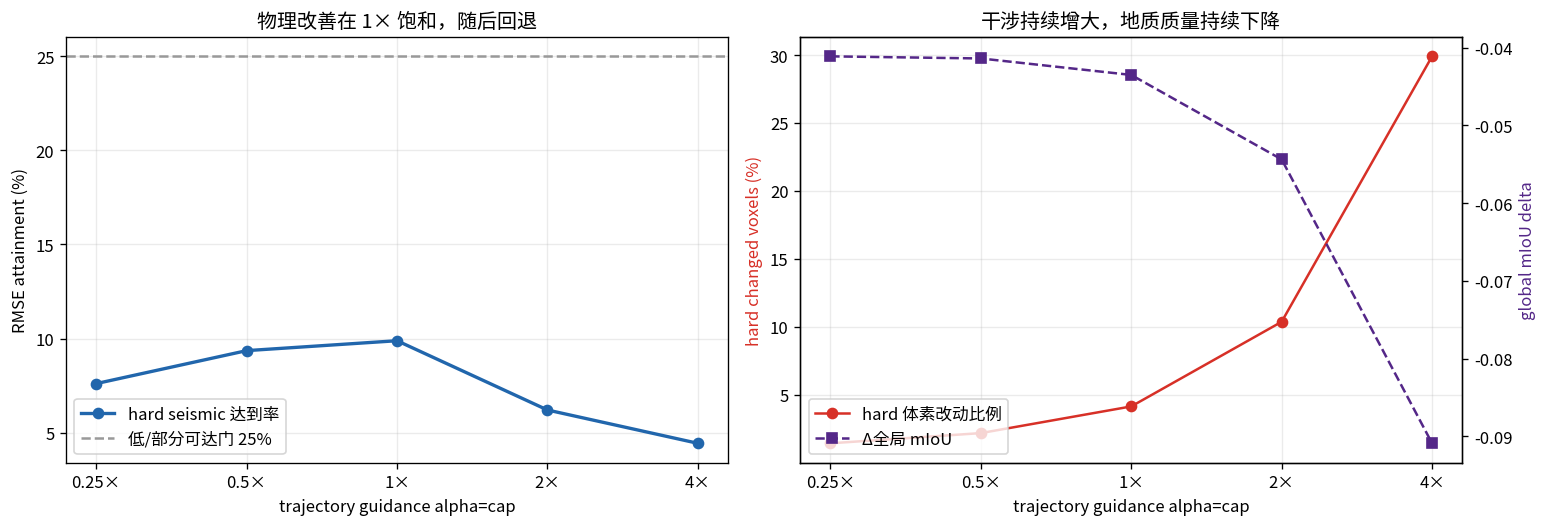

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = ladder_physics["alpha"].to_numpy()

axes[0].plot(x, 100 * ladder_physics["attainment"], "o-", color="#2166ac", linewidth=2, label="hard seismic 达到率")
axes[0].axhline(25, color="#999999", linestyle="--", label="低/部分可达门 25%")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(x, [f"{v:g}×" for v in x])
axes[0].set_xlabel("trajectory guidance alpha=cap")
axes[0].set_ylabel("RMSE attainment (%)")
axes[0].set_title("物理改善在 1× 饱和，随后回退")
axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].plot(x, 100 * ladder_physics["changed_from_baseline_fraction"], "o-", color="#d73027", label="hard 体素改动比例")
ax2 = axes[1].twinx()
geology_rows = geo_index.loc[ladder_physics["id"]]
delta_miou = geology_rows["global_mean_iou"].to_numpy() - baseline_geo["global_mean_iou"]
ax2.plot(x, delta_miou, "s--", color="#542788", label="Δ全局 mIoU")
axes[1].set_xscale("log", base=2); axes[1].set_xticks(x, [f"{v:g}×" for v in x])
axes[1].set_xlabel("trajectory guidance alpha=cap")
axes[1].set_ylabel("hard changed voxels (%)", color="#d73027")
ax2.set_ylabel("global mIoU delta", color="#542788")
axes[1].set_title("干涉持续增大，地质质量持续下降")
axes[1].grid(alpha=0.25)
lines = axes[1].get_lines() + ax2.get_lines()
axes[1].legend(lines, [line.get_label() for line in lines], loc="lower left")
plt.tight_layout(); plt.show()

## 3. 全岩性三维外露界面

下图不是只显示 label 9。它提取所有非空气岩性的外边界和类别接触面，以统一固定相机显示六个代表模型。为控制 Notebook 大小，每个类别采用确定性等距抽样；颜色表示 raw lithology label。

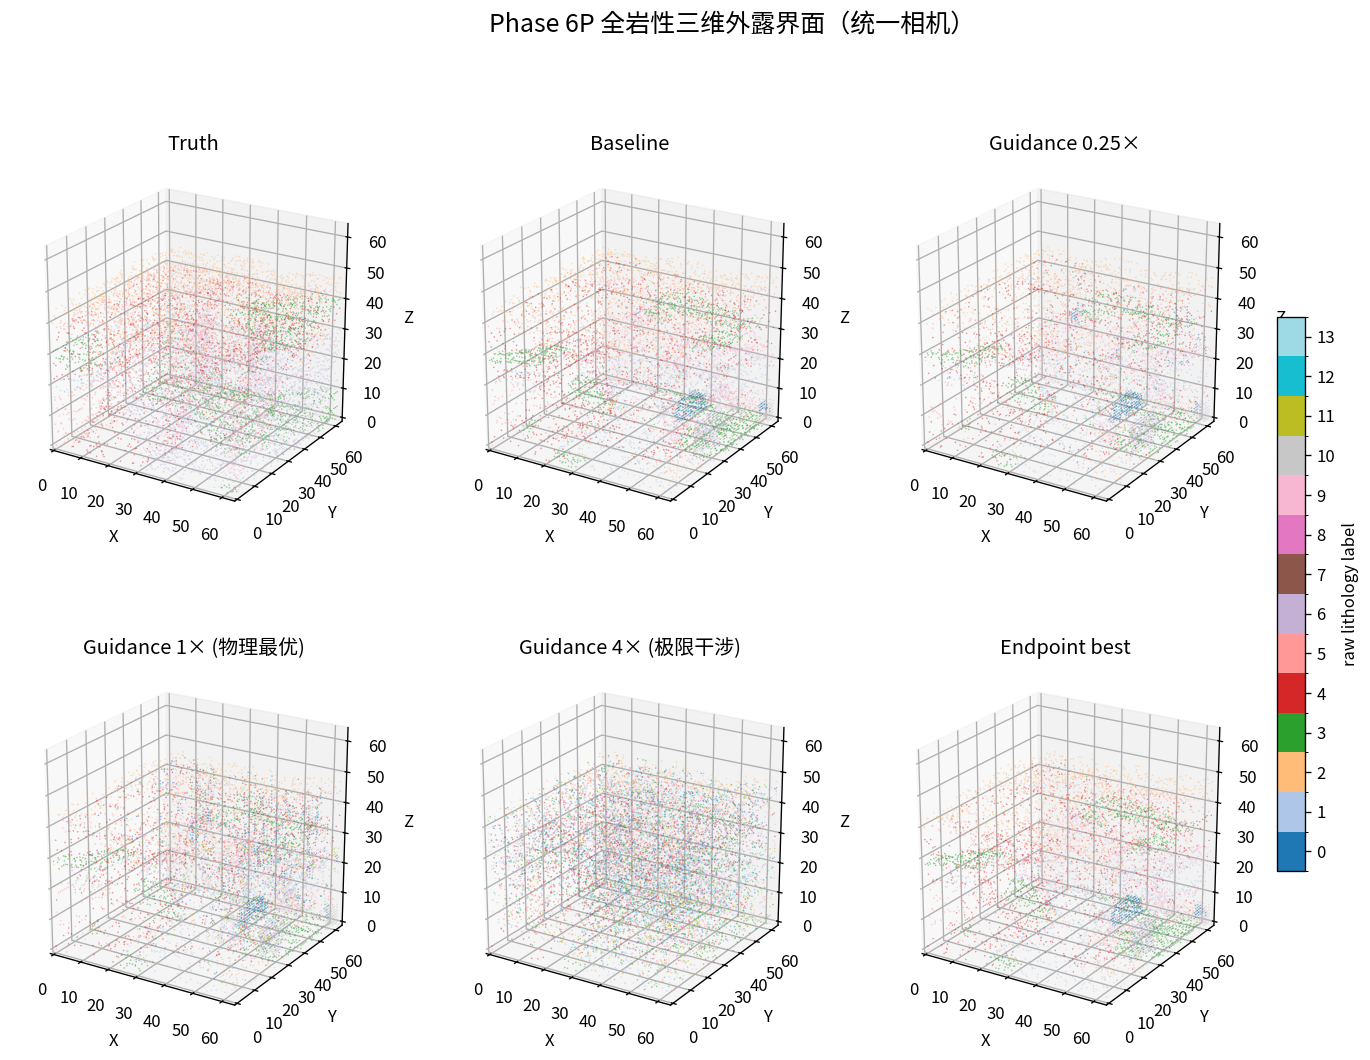

In [4]:
truth = load_volume(TRUTH_PATH).astype(np.int16)
volumes = {
    "Truth": truth,
    "Baseline": load_volume(LADDER / "baseline_sample.pt").astype(np.int16),
    "Guidance 0.25×": load_volume(LADDER / "ratio025_sample.pt").astype(np.int16),
    "Guidance 1× (物理最优)": load_volume(LADDER / "ratio100_sample.pt").astype(np.int16),
    "Guidance 4× (极限干涉)": load_volume(LADDER / "ratio400_sample.pt").astype(np.int16),
    "Endpoint best": load_volume(ENDPOINT / "best_sample.pt").astype(np.int16),
}

def interface_mask(volume):
    valid = volume >= 0
    boundary = np.zeros_like(valid, dtype=bool)
    for axis in range(3):
        left = [slice(None)] * 3; right = [slice(None)] * 3
        left[axis] = slice(0, -1); right[axis] = slice(1, None)
        left, right = tuple(left), tuple(right)
        different = volume[left] != volume[right]
        boundary[left] |= different & valid[left]
        boundary[right] |= different & valid[right]
        edge0 = [slice(None)] * 3; edge1 = [slice(None)] * 3
        edge0[axis] = 0; edge1[axis] = -1
        boundary[tuple(edge0)] |= valid[tuple(edge0)]
        boundary[tuple(edge1)] |= valid[tuple(edge1)]
    return boundary & valid

def stratified_interface_points(volume, max_points=12000):
    mask = interface_mask(volume)
    labels = np.unique(volume[mask])
    budget = max(1, max_points // max(len(labels), 1))
    point_parts, label_parts = [], []
    for label in labels:
        points = np.argwhere(mask & (volume == label))
        if len(points) > budget:
            points = points[np.linspace(0, len(points) - 1, budget, dtype=int)]
        point_parts.append(points)
        label_parts.append(np.full(len(points), label))
    return np.concatenate(point_parts), np.concatenate(label_parts)

cmap = plt.get_cmap("tab20", 14)
norm = mcolors.BoundaryNorm(np.arange(-0.5, 14.5, 1), cmap.N)
fig = plt.figure(figsize=(16, 10))
for index, (title, volume) in enumerate(volumes.items(), start=1):
    ax = fig.add_subplot(2, 3, index, projection="3d")
    points, point_labels = stratified_interface_points(volume)
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=point_labels, cmap=cmap, norm=norm,
               s=0.9, alpha=0.48, linewidths=0, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_xlim(0, 63); ax.set_ylim(0, 63); ax.set_zlim(0, 63)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=22, azim=-58)
scalar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(scalar, ax=fig.axes, shrink=0.60, pad=0.02, ticks=range(14))
cbar.set_label("raw lithology label")
fig.suptitle("Phase 6P 全岩性三维外露界面（统一相机）", fontsize=15, y=0.98)
plt.show()

**观察要点：** 0.25× 到 1× 已经发生明显类别重排，但并没有向 Truth 的主体结构收敛；4× 出现大范围碎裂和类别重组。这与“强制导已经得到另一组物理等价的合理地质”不同——4× 的地震拟合本身也比 1× 更差。

## 4. label 9 三维目标体：真值、基线、完整强度阶梯与 endpoint

采用旧总结 Notebook 相同的固定相机点云口径。标题同时显示 label-9 预测体积和真值相对 IoU。

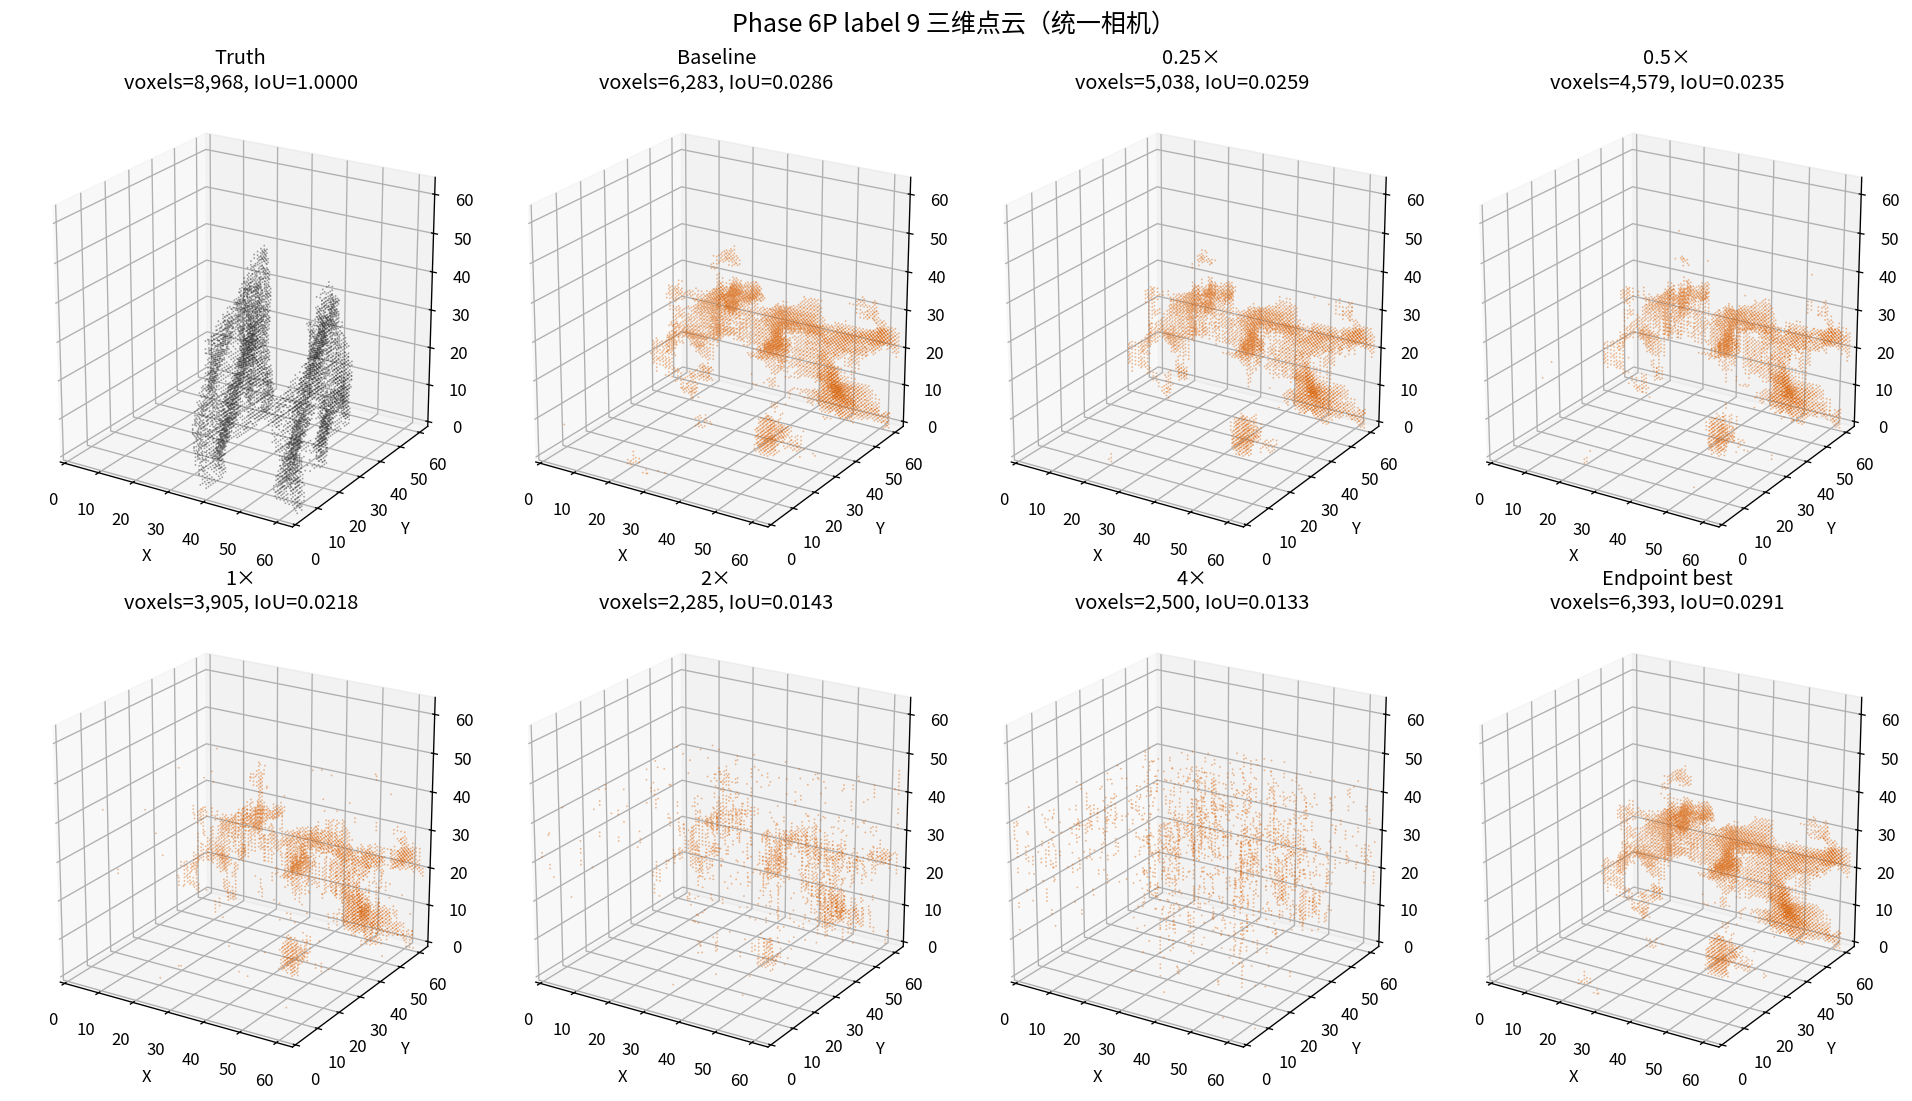

In [5]:
target_volumes = [
    ("Truth", truth),
    ("Baseline", volumes["Baseline"]),
    ("0.25×", volumes["Guidance 0.25×"]),
    ("0.5×", load_volume(LADDER / "ratio050_sample.pt").astype(np.int16)),
    ("1×", volumes["Guidance 1× (物理最优)"]),
    ("2×", load_volume(LADDER / "ratio200_sample.pt").astype(np.int16)),
    ("4×", volumes["Guidance 4× (极限干涉)"]),
    ("Endpoint best", volumes["Endpoint best"]),
]
iou_by_role = {"Truth": 1.0, "Baseline": baseline_geo["target_iou"]}
for role in ["ratio025", "ratio050", "ratio100", "ratio200", "ratio400"]:
    iou_by_role[role.replace("ratio", "").lstrip("0") or "0"] = geo_index.loc[role, "target_iou"]
title_to_iou = {
    "Truth": 1.0, "Baseline": baseline_geo["target_iou"],
    "0.25×": geo_index.loc["ratio025", "target_iou"],
    "0.5×": geo_index.loc["ratio050", "target_iou"],
    "1×": geo_index.loc["ratio100", "target_iou"],
    "2×": geo_index.loc["ratio200", "target_iou"],
    "4×": geo_index.loc["ratio400", "target_iou"],
    "Endpoint best": endpoint_geo["target_iou"],
}

def scatter_target(ax, volume, title, label=9, max_points=7000):
    points = np.argwhere(volume == label)
    if len(points) > max_points:
        points = points[np.linspace(0, len(points) - 1, max_points, dtype=int)]
    if len(points):
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1.2, alpha=0.42,
                   c="#d95f02" if title != "Truth" else "#252525", linewidths=0, rasterized=True)
    ax.set_title(f"{title}\nvoxels={np.sum(volume == label):,}, IoU={title_to_iou[title]:.4f}")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_xlim(0, 63); ax.set_ylim(0, 63); ax.set_zlim(0, 63)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=22, azim=-58)

fig = plt.figure(figsize=(16, 9.5))
for index, (title, volume) in enumerate(target_volumes, start=1):
    scatter_target(fig.add_subplot(2, 4, index, projection="3d"), volume, title)
fig.suptitle("Phase 6P label 9 三维点云（统一相机）", fontsize=15, y=0.98)
plt.tight_layout(); plt.show()

**三维结果非常直接：** 物理最优的 1× 并没有补回 Truth 中缺失的 label-9 主体；2×/4× 进一步删除并碎裂目标体。endpoint-best 只改变少量体素，其目标 IoU 几乎等于基线。

## 5. 硬地震剖面：观测、基线、物理最优、极限制导和 endpoint

固定显示中央 `y=32` 剖面。第一行是硬标签正演结果；第二行是相对于观测的残差，使用统一色标。

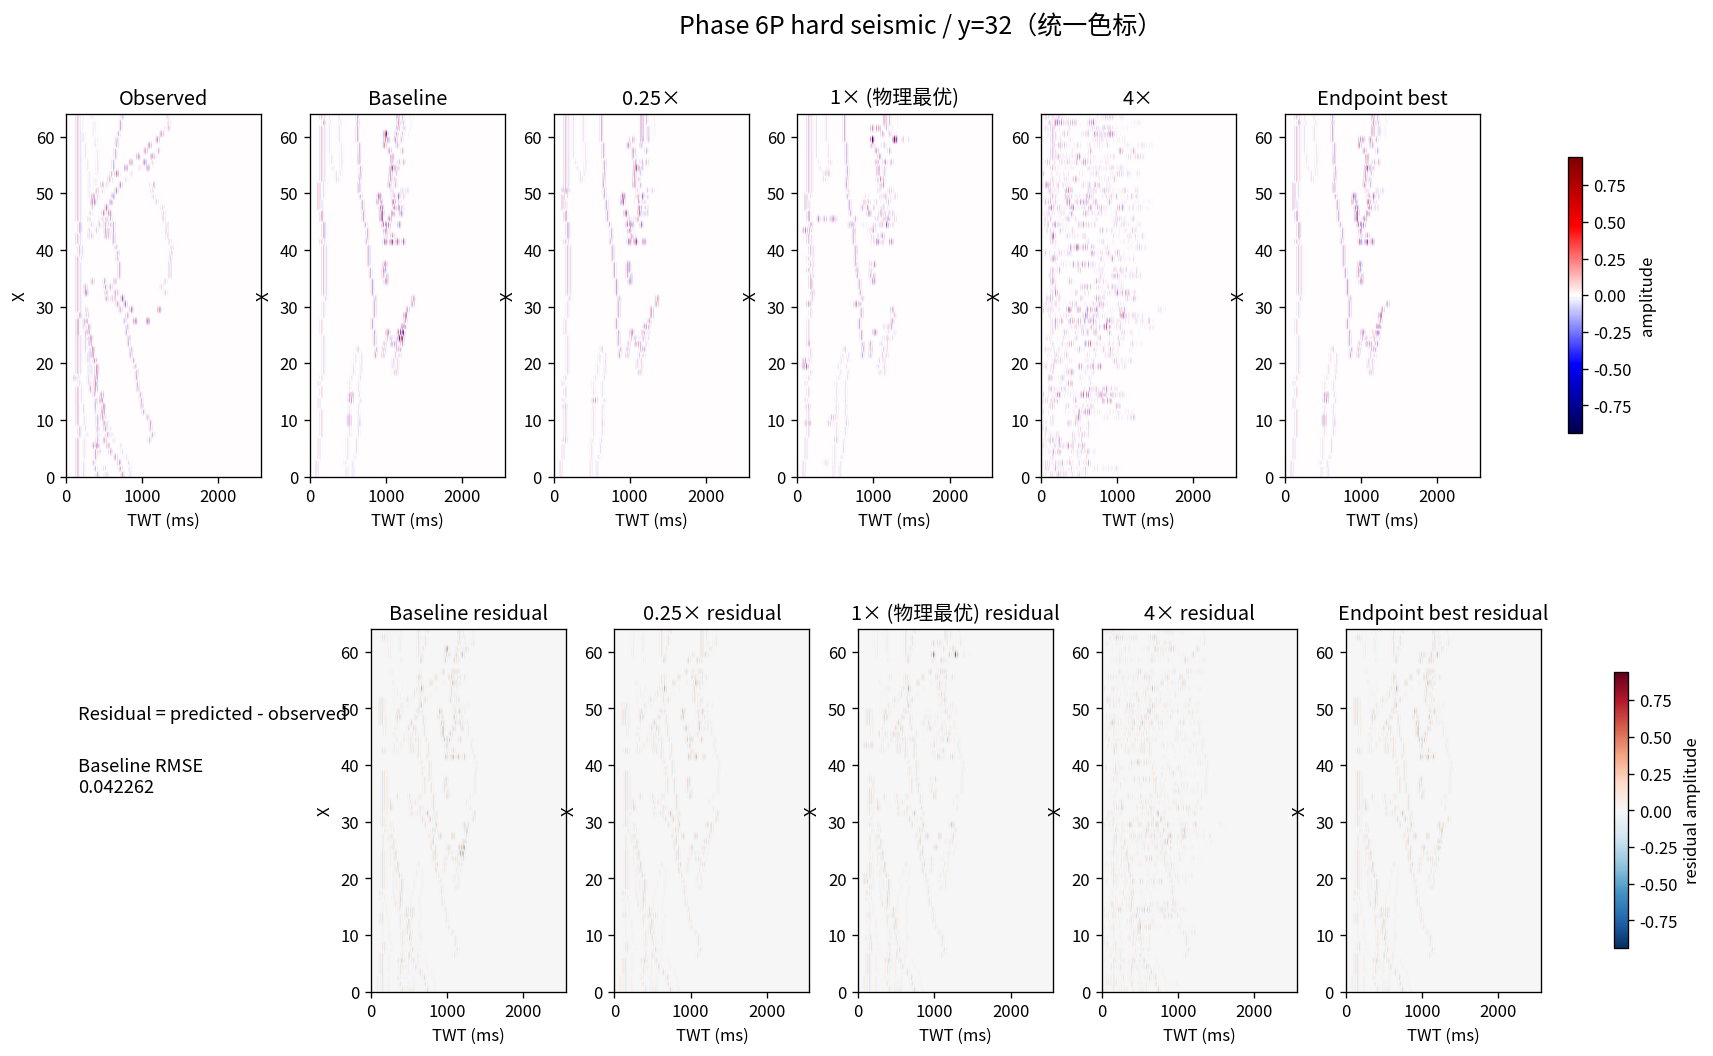

In [6]:
observed = load_volume(OBSERVATION / "observed_seismic.pt")
seismic_fields = {
    "Baseline": load_volume(LADDER / "baseline_hard_seismic.pt"),
    "0.25×": load_volume(LADDER / "ratio025_hard_seismic.pt"),
    "1× (物理最优)": load_volume(LADDER / "ratio100_hard_seismic.pt"),
    "4×": load_volume(LADDER / "ratio400_hard_seismic.pt"),
    "Endpoint best": load_volume(ENDPOINT / "best_hard_seismic.pt"),
}
y_index = observed.shape[1] // 2
observed_section = observed[:, y_index, :]
sections = {name: field[:, y_index, :] for name, field in seismic_fields.items()}
amp_limit = max(np.abs(observed_section).max(), *(np.abs(value).max() for value in sections.values()))
residuals = {name: value - observed_section for name, value in sections.items()}
residual_limit = max(np.abs(value).max() for value in residuals.values())
extent = [0, observed_section.shape[1] * 8, 0, observed_section.shape[0]]

fig, axes = plt.subplots(
    2, 6, figsize=(19, 9.5),
    gridspec_kw={"hspace": 0.42, "wspace": 0.25},
)
top_items = [("Observed", observed_section), *sections.items()]
for ax, (title, data) in zip(axes[0], top_items):
    image = ax.imshow(data, aspect="auto", origin="lower", cmap="seismic",
                      vmin=-amp_limit, vmax=amp_limit, extent=extent)
    ax.set_title(title); ax.set_xlabel("TWT (ms)"); ax.set_ylabel("X")
fig.colorbar(image, ax=axes[0].ravel().tolist(), shrink=0.76, label="amplitude")

axes[1, 0].axis("off")
axes[1, 0].text(0.05, 0.75, "Residual = predicted - observed", fontsize=11)
axes[1, 0].text(0.05, 0.55, f"Baseline RMSE\n{ladder_physics.iloc[0]['baseline_rmse']:.6f}", fontsize=11)
for ax, (title, data) in zip(axes[1, 1:], residuals.items()):
    image2 = ax.imshow(data, aspect="auto", origin="lower", cmap="RdBu_r",
                       vmin=-residual_limit, vmax=residual_limit, extent=extent)
    ax.set_title(f"{title} residual"); ax.set_xlabel("TWT (ms)"); ax.set_ylabel("X")
fig.colorbar(image2, ax=axes[1, 1:].ravel().tolist(), shrink=0.76, label="residual amplitude")
fig.suptitle(f"Phase 6P hard seismic / y={y_index}（统一色标）", fontsize=15, y=0.97)
plt.show()

剖面中 1× 的局部残差比 0.25× 略小，但整体仍与 baseline 十分接近；4× 和 endpoint 并未形成接近 observed 的硬响应。这与 RMSE 最高只达到 9.88% 一致。

## 6. Endpoint 的 soft/hard 分叉

endpoint 直接优化连续状态，避免了“32 步轨迹中的基础速度太强”这一解释。每个温度区间内 soft seismic 都下降；hard decode 只在前 15 步略有改善，随后迅速恶化。

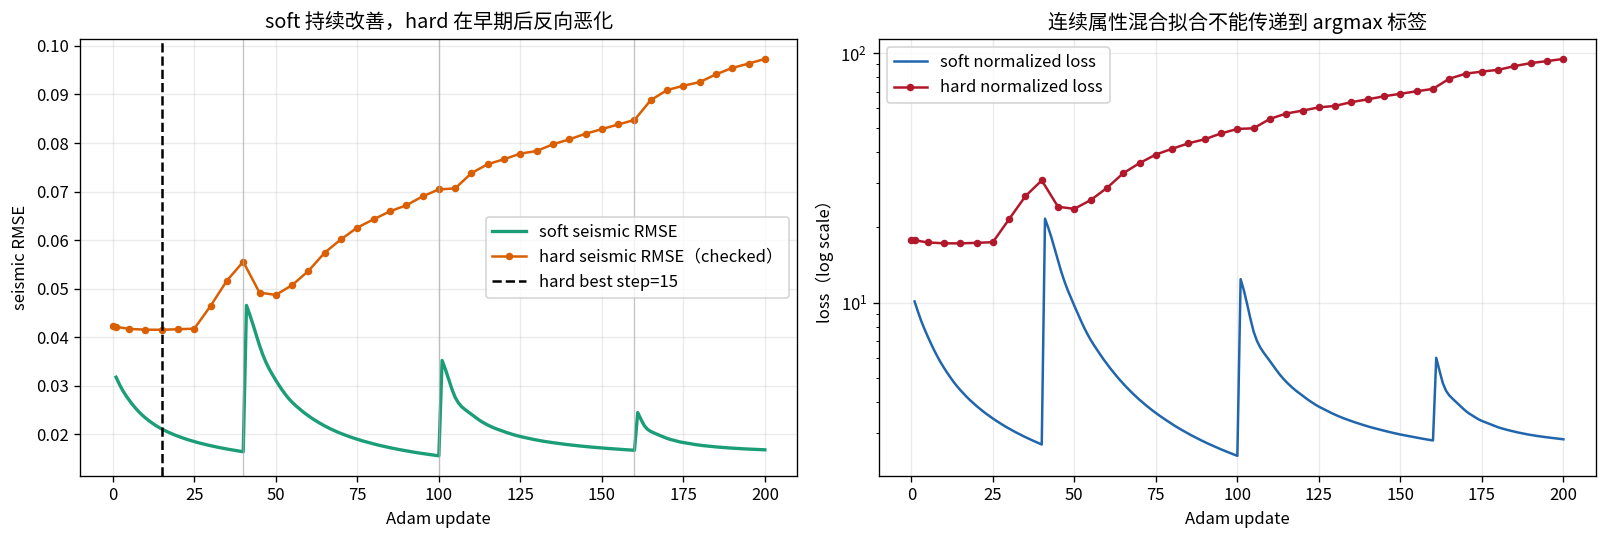

soft RMSE step1 -> step200: 0.03177387 -> 0.01682162 (47.1% reduction)
hard best RMSE: 0.04154664; hard final RMSE: 0.09732279


In [7]:
checked = endpoint_trace.dropna(subset=["hard_rmse_amplitude"])
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

axes[0].plot(endpoint_trace["step"], endpoint_trace["soft_seismic_rmse_amplitude"],
             color="#1b9e77", linewidth=2, label="soft seismic RMSE")
axes[0].plot(checked["step"], checked["hard_rmse_amplitude"], "o-",
             color="#d95f02", markersize=3.5, label="hard seismic RMSE（checked）")
axes[0].axvline(endpoint_config["best_step"], color="black", linestyle="--",
                label=f"hard best step={endpoint_config['best_step']}")
for boundary in (40, 100, 160):
    axes[0].axvline(boundary, color="#aaaaaa", linewidth=0.8, alpha=0.7)
axes[0].set_xlabel("Adam update"); axes[0].set_ylabel("seismic RMSE")
axes[0].set_title("soft 持续改善，hard 在早期后反向恶化")
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(endpoint_trace["step"], endpoint_trace["soft_loss"], color="#2166ac", label="soft normalized loss")
axes[1].plot(checked["step"], checked["hard_loss"], "o-", color="#b2182b", markersize=3.5, label="hard normalized loss")
axes[1].set_yscale("log")
axes[1].set_xlabel("Adam update"); axes[1].set_ylabel("loss（log scale）")
axes[1].set_title("连续属性混合拟合不能传递到 argmax 标签")
axes[1].legend(); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

first_soft = endpoint_trace.loc[endpoint_trace["step"] == 1, "soft_seismic_rmse_amplitude"].iloc[0]
final_soft = endpoint_trace.loc[endpoint_trace["step"] == 200, "soft_seismic_rmse_amplitude"].iloc[0]
final_hard = endpoint_trace.loc[endpoint_trace["step"] == 200, "hard_rmse_amplitude"].iloc[0]
print(f"soft RMSE step1 -> step200: {first_soft:.8f} -> {final_soft:.8f} ({1-final_soft/first_soft:.1%} reduction)")
print(f"hard best RMSE: {endpoint_phys['candidate_rmse']:.8f}; hard final RMSE: {final_hard:.8f}")

## 7. 为什么不能用“非唯一性”单独解释？

若当前结果主要是地球物理非唯一性，应满足：

1. 最终 **hard-label 正演**已经充分接近观测；
2. 三维岩性仍与真值不同。

当前不满足第一条。轨迹阶梯的最高 hard-seismic 达到率只有 **9.88%**，endpoint 只有 **1.69%**。因此 notebook 中“制导地震仍更像基线”的直接原因是样本尚未到达观测流形。

2×/4× 尤其有诊断意义：场更新范数已经达到所需残差的 `1.006/1.081` 倍，说明干涉幅度不小；但更新与正确残差方向的余弦只有 `0.563/0.581`。这属于**方向错位**，不是另一组同样正确的物理解。

非唯一性依然会在真正到达观测流形后存在，但本实验还没进入那个区域。

## 8. Phase 2 为什么好，而 Phase 3/4/6P 不好？

- Phase 2 的全分辨率双属性 oracle 在每个体素直接给出类别可辨识码字，梯度与 embedding 类别边界近似局部对齐。
- Phase 3 模糊后，一个观测体素混合邻域类别，边界和小尺度几何丢失。
- Phase 4 地震经过阻抗界面、时深映射和子波卷积，约束的是界面/对比，而不是每个体素的唯一岩性。
- 当前 frozen flow 没有训练过“地震残差应该对应什么地质速度修正”。弱制导跨不过类别边界，强制导则破坏生成器先验。
- endpoint 证明 soft mixture 可以绕过 hard codebook 拟合观测；低 soft loss 不会自动产生正确 hard labels。

因此 Phase 6P 支持进入训练型 adapter 路线，但训练目标必须同时包含 hard-aware all-class 对齐与物理一致性，不能只继续增加 inference alpha。

## 9. 工程验收与结论边界

两个 runner 的工程门均为 PASS：基模 hash 前后相同、无基模梯度、条件违规为零、历史 alpha-zero 基线精确、0.25× 样本逐体素回归原 Phase 4C。物理 runner 不使用地质真值选级；真值指标来自运行后的独立 audit。

这是一组同一样本、truth-derived inverse-crime 的机制诊断。它证明当前 frozen generator + soft decoder + inference controller 在明显更强的协议下仍低可达，但不是数学上的绝对不可达证明，也不代表所有离散反演器必然失败。

In [8]:
gates = pd.DataFrame([
    {"实验": "Endpoint 200-step", **endpoint_config["engineering_gates"]},
    {"实验": "Trajectory 0.25-4×", **ladder_config["engineering_gates"]},
]).set_index("实验").T
display(gates)

artifacts = pd.DataFrame([
    {"内容": "Phase 6P 规范", "路径": "docs/PHASE6P_INFERENCE_LIMIT_SPEC.md"},
    {"内容": "Phase 6P 人工报告", "路径": "docs/PHASE6P_REPORT.md"},
    {"内容": "Endpoint 权威 run", "路径": str(ENDPOINT.relative_to(PROJECT))},
    {"内容": "Trajectory ladder run", "路径": str(LADDER.relative_to(PROJECT))},
    {"内容": "本 Notebook 生成器", "路径": "scripts/reports/build_phase6p_summary_notebook.py"},
])
display(artifacts)

实验,Endpoint 200-step,Trajectory 0.25-4×
all_updates_completed,True,NaN
base_model_gradients_absent,True,True
base_model_hash_unchanged,True,True
best_conditions_exact,True,NaN
hard_loss_nonregression,True,NaN
historical_baseline_exact,True,True
initial_conditions_exact,True,NaN
minimum_hard_loss_selection_exact,True,NaN
optimizer_initial_hard_exact,True,NaN
all_conditions_exact,NaN,True


,内容,路径
0,Phase 6P 规范,docs/PHASE6P_INFERENCE_LIMIT_SPEC.md
1,Phase 6P 人工报告,docs/PHASE6P_REPORT.md
2,Endpoint 权威 run,experiments/stage6_geo_adapter/runs/cond_gener...
3,Trajectory ladder run,experiments/stage6_geo_adapter/runs/cond_gener...
4,本 Notebook 生成器,scripts/reports/build_phase6p_summary_notebook.py


---

## 最终结论

**已有非常具体的负结果：** 把推理期地震制导提高到先验速度的 4 倍，并没有让 hard seismic 朝观测充分收敛；物理最优停在 1 倍、达到率仅 9.88%，而三维地质随强度增加持续退化。直接 endpoint 优化又证明 soft seismic 的显著下降可以与 hard seismic 的恶化同时发生。

所以当前缺口不能主要归因于“已经得到物理等价但地质不同的非唯一解”。首先需要通过学习让地震信息、生成器 proposal 和 hard decoder 对齐；之后才有资格研究观测流形上的地球物理非唯一性。正式训练尚未开始。